In [24]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# BMW Global Sales Analysis - Section B

## Analysis Objective

This section aims to answer two questions:

1. Which BMW models show stronger price elasticity based on the relationship between average price and units sold?
2. Does this price-sales relationship vary under different GDP growth conditions?

## 1. Load data and clean
Only the columns needed for this question are kept.
GDP growth is grouped into three levels: Low, Medium, and High.

In [25]:
# Load data
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf

file_path = '/content/drive/MyDrive/bmw/bmw_global_sales_2018_2025.csv'
df = pd.read_csv(file_path)

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

sns.set_style("whitegrid")


# Basic cleaning

qB = df[[
    "Year", "Month", "Region", "Model",
    "Units_Sold", "Avg_Price_EUR", "GDP_Growth"
]].copy()


qB = qB.dropna().copy()
qB = qB[
    (qB["Units_Sold"] > 0) &
    (qB["Avg_Price_EUR"] > 0)
].copy()



qB_trim = qB.copy()

for col in ["Units_Sold", "Avg_Price_EUR"]:
    lower = qB_trim[col].quantile(0.01)
    upper = qB_trim[col].quantile(0.99)
    qB_trim = qB_trim[
        (qB_trim[col] >= lower) &
        (qB_trim[col] <= upper)
    ].copy()


# Log transformation
qB_trim["log_units"] = np.log(qB_trim["Units_Sold"])
qB_trim["log_price"] = np.log(qB_trim["Avg_Price_EUR"])


# Create GDP levels
qB_trim["GDP_Level"] = pd.qcut(
    qB_trim["GDP_Growth"],
    q=3,
    labels=["Low", "Medium", "High"]
)

qB_trim["GDP_Level"] = pd.Categorical(
    qB_trim["GDP_Level"],
    categories=["Low", "Medium", "High"],
    ordered=True
)


### 1.1 Diagnostic check by model


This helps confirm that each model has enough observations and that price is not completely constant within model.

In [26]:
# Diagnostic check by model
model_check = (
    qB_trim.groupby("Model")
           .agg(
               n_obs=("Model", "size"),
               price_unique=("Avg_Price_EUR", "nunique"),
               price_std=("Avg_Price_EUR", "std"),
               units_std=("Units_Sold", "std"),
               mean_price=("Avg_Price_EUR", "mean"),
               mean_units=("Units_Sold", "mean")
           )
           .reset_index()
)

model_check["price_cv"] = model_check["price_std"] / model_check["mean_price"]
model_check["units_cv"] = model_check["units_std"] / model_check["mean_units"]

print("Diagnostic check by model:")
display(model_check.round(3))

Diagnostic check by model:


,Model,n_obs,price_unique,price_std,units_std,mean_price,mean_units,price_cv,units_cv
0,3 Series,379,359,1163.643,3124.973,47987.968,7795.707,0.024,0.401
1,5 Series,380,367,1141.772,3119.716,61935.203,7907.179,0.018,0.395
2,MINI,343,328,1094.589,2968.196,42218.601,7759.560,0.026,0.383
3,X3,376,362,1116.201,3072.856,58021.205,7858.176,0.019,0.391
4,X5,379,357,1131.836,2993.910,68932.900,8037.844,0.016,0.372
5,X7,344,328,1046.893,3138.045,91852.070,8025.892,0.011,0.391
6,i4,372,360,1113.800,3072.941,64933.360,8181.608,0.017,0.376
7,iX,375,358,1155.934,3148.838,74975.211,8101.011,0.015,0.389


## 2. Price Elasticity Analysis

To estimate model-level price elasticity, the following log-log specification is used:

`log_units ~ log_price + C(Year) + C(Region)`

In [27]:
# Define elasticity function
def estimate_elasticity_fe(group, min_obs=24):
    result = {
        "n_obs": len(group),
        "elasticity": np.nan,
        "p_value": np.nan,
        "r2": np.nan,
        "ci_low": np.nan,
        "ci_high": np.nan
    }

    if len(group) < min_obs:
        return result

    if group["log_price"].nunique() < 5:
        return result

    try:
        model = smf.ols(
            "log_units ~ log_price + C(Year) + C(Region)",
            data=group
        ).fit()

        ci_low, ci_high = model.conf_int().loc["log_price"]

        result["elasticity"] = model.params["log_price"]
        result["p_value"] = model.pvalues["log_price"]
        result["r2"] = model.rsquared
        result["ci_low"] = ci_low
        result["ci_high"] = ci_high

    except Exception:
        pass

    return result


def run_group_estimation(data, group_cols, min_obs=24):
    rows = []

    for keys, group in data.groupby(group_cols, observed=True):
        if not isinstance(keys, tuple):
            keys = (keys,)

        row = {}
        for col, key in zip(group_cols, keys):
            row[col] = key

        row.update(estimate_elasticity_fe(group, min_obs=min_obs))
        rows.append(row)

    return pd.DataFrame(rows)


# Overall elasticity by model
overall_result = run_group_estimation(
    data=qB_trim,
    group_cols=["Model"],
    min_obs=24
).sort_values("elasticity").reset_index(drop=True)

print("Overall price elasticity by model:")
display(overall_result.round(3))

Overall price elasticity by model:


,Model,n_obs,elasticity,p_value,r2,ci_low,ci_high
0,iX,375,-2.637,0.069,0.061,-5.482,0.209
1,MINI,343,-1.112,0.204,0.048,-2.831,0.607
2,X3,376,-0.763,0.515,0.020,-3.070,1.543
3,5 Series,380,-0.762,0.540,0.044,-3.204,1.681
4,i4,372,-0.296,0.819,0.034,-2.842,2.250
5,3 Series,379,1.034,0.278,0.032,-0.836,2.905
6,X7,344,1.868,0.372,0.029,-2.241,5.977
7,X5,379,3.290,0.014,0.046,0.678,5.903


### 2.1 Overall elasticity by model

The following table and figure compare the overall price elasticity estimates across BMW models.

Negative coefficients are more consistent with a conventional price-sensitive pattern, while positive coefficients indicate a positive observed price-sales association.

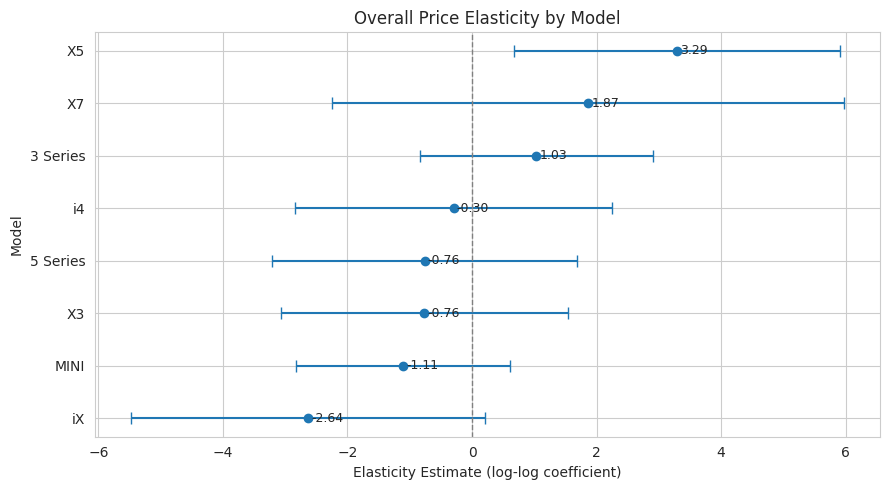

In [28]:

# Plot overall elasticity by model
plot_df = overall_result.dropna(subset=["elasticity"]).copy()
plot_df = plot_df.sort_values("elasticity", ascending=True)

plt.figure(figsize=(9, 5))

plt.errorbar(
    x=plot_df["elasticity"],
    y=plot_df["Model"],
    xerr=[
        plot_df["elasticity"] - plot_df["ci_low"],
        plot_df["ci_high"] - plot_df["elasticity"]
    ],
    fmt="o",
    capsize=4
)

plt.axvline(0, color="gray", linestyle="--", linewidth=1)

for _, row in plot_df.iterrows():
    plt.text(
        row["elasticity"] + 0.05,
        row["Model"],
        f"{row['elasticity']:.2f}",
        va="center",
        fontsize=9
    )

plt.title("Overall Price Elasticity by Model")
plt.xlabel("Elasticity Estimate (log-log coefficient)")
plt.ylabel("Model")
plt.tight_layout()
plt.show()


## 3. Elasticity under Different GDP Conditions

To examine whether price elasticity changes across economic environments, GDP growth is grouped into three levels-low,medium and high.
The same elasticity model is then estimated within each GDP level for each BMW model.

In [29]:

# GDP-level elasticity by model
gdp_result = run_group_estimation(
    data=qB_trim,
    group_cols=["GDP_Level", "Model"],
    min_obs=20
).sort_values(["GDP_Level", "elasticity"]).reset_index(drop=True)


# GDP pivot table
gdp_pivot = gdp_result.pivot(
    index="Model",
    columns="GDP_Level",
    values="elasticity"
)

gdp_pivot = gdp_pivot[["Low", "Medium", "High"]]

print("GDP-level elasticity pivot table:")
display(gdp_pivot.round(3))


GDP-level elasticity pivot table:


GDP_Level,Low,Medium,High
Model,,,
3 Series,1.001,2.095,0.175
5 Series,1.271,-0.774,-1.923
MINI,-2.023,0.583,-2.455
X3,-0.013,-0.176,-1.435
X5,1.982,9.363,0.574
X7,0.353,2.336,2.726
i4,1.329,-2.733,0.066
iX,-1.626,-2.699,-3.901


### 3.1 GDP-level elasticity comparison

The heatmap below compares how model-level elasticity changes across Low, Medium, and High GDP growth conditions.

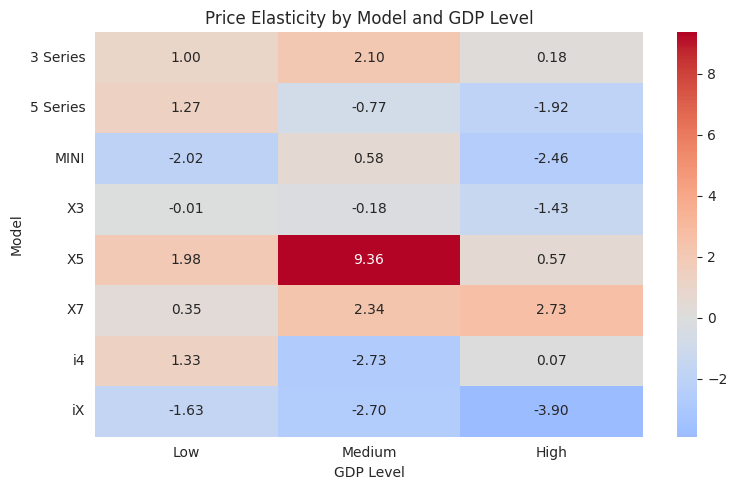

In [30]:
# GDP-level heatmap
plt.figure(figsize=(8, 5))
sns.heatmap(
    gdp_pivot,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)
plt.title("Price Elasticity by Model and GDP Level")
plt.xlabel("GDP Level")
plt.ylabel("Model")
plt.tight_layout()
plt.show()


## 4. Visual Diagnostics

To make the model results easier to interpret, two representative scatter plots are shown:

- `iX`: the strongest negative relationship,
- `X5`: the strongest positive relationship.

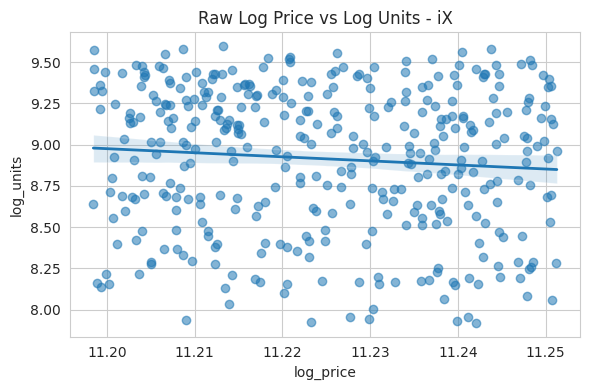

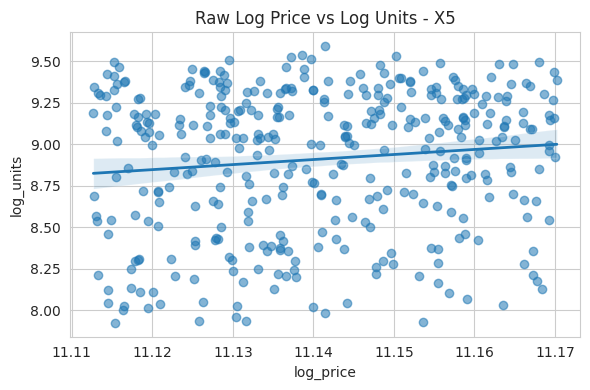

Overall result with interpretation:


,Model,n_obs,elasticity,p_value,r2,Interpretation
0,iX,375,-2.637,0.069,0.061,More price-sensitive (negative)
1,MINI,343,-1.112,0.204,0.048,More price-sensitive (negative)
2,X3,376,-0.763,0.515,0.020,Moderately negative
3,5 Series,380,-0.762,0.540,0.044,Moderately negative
4,i4,372,-0.296,0.819,0.034,Moderately negative
5,3 Series,379,1.034,0.278,0.032,Positive association
6,X7,344,1.868,0.372,0.029,Positive association
7,X5,379,3.290,0.014,0.046,Positive association


Final summary
Most negative elasticity model: iX (-2.64)
Closest to zero elasticity model: i4 (-0.30)
Strongest positive association: X5 (3.29)
Note: these are descriptive price-volume relationships, not strict causal effects.
GDP-level results are supplementary checks rather than the main conclusion.


In [31]:

# Representative scatter plots
def plot_model_scatter(data, model_name):
    temp = data[data["Model"] == model_name].copy()

    plt.figure(figsize=(6, 4))
    sns.regplot(
        data=temp,
        x="log_price",
        y="log_units",
        scatter_kws={"alpha": 0.55},
        line_kws={"linewidth": 2}
    )
    plt.title(f"Raw Log Price vs Log Units - {model_name}")
    plt.xlabel("log_price")
    plt.ylabel("log_units")
    plt.tight_layout()
    plt.show()

for model_name in ["iX", "X5"]:
    plot_model_scatter(qB_trim, model_name)


# Add simple interpretation labels
def interpret_elasticity(x):
    if pd.isna(x):
        return "Not available"
    elif x < -1:
        return "More price-sensitive (negative)"
    elif -1 <= x < -0.2:
        return "Moderately negative"
    elif -0.2 <= x <= 0.2:
        return "Near zero"
    else:
        return "Positive association"

overall_result["Interpretation"] = overall_result["elasticity"].apply(interpret_elasticity)

print("Overall result with interpretation:")
display(
    overall_result[[
        "Model", "n_obs", "elasticity", "p_value", "r2", "Interpretation"
    ]].round(3)
)


print("Final summary")
print(f"Most negative elasticity model: {most_negative['Model']} ({most_negative['elasticity']:.2f})")
print(f"Closest to zero elasticity model: {closest_zero['Model']} ({closest_zero['elasticity']:.2f})")
print(f"Strongest positive association: {most_positive['Model']} ({most_positive['elasticity']:.2f})")
print("Note: these are descriptive price-volume relationships, not strict causal effects.")
print("GDP-level results are supplementary checks rather than the main conclusion.")

## 5. Conclusion


1. Price-sales relationships vary across BMW models.
2. `iX` shows the strongest negative observed elasticity, while `X5` shows the strongest positive observed association.
3. GDP-level results suggest that the strength and direction of elasticity may change across economic conditions, although these patterns should be interpreted as descriptive rather than strictly causal.